# Trabajo de Visión Artificial

## Dataset
[Dataset de señales de tráfico - kaggle](https://www.kaggle.com/datasets/msalman97/dataset-for-traffic-sign-master-app/data)

### Info obtenida del datacard
Este conjunto de datos consiste en más de 60 señales de tráfico. El conjunto fue creado utilizando señales del **German Traffic Sign Recognition Benchmark Dataset**, señales recolectadas localmente, señales de distintos conjuntos de datos y imágenes de señales obtenidas de Internet. Las imágenes fueron aumentadas utilizando un script en Python.

Las imágenes aumentadas se procesaron de la siguiente manera:

**Redimensionamiento:** 32x32, 64x64, 128x128, 256x256

**Reducción de brillo:** -60%

**Aumento de brillo:** +60%

**Desenfoque aplicado a:** imágenes de 128x128, 256x256 y originales

**Niebla añadida a:** imágenes de 128x128, 256x256 y originales

**Alteración de color:** brillo, contraste y color con valores de 1.8

Después de la ampliación, las imágenes se renombran así:
`[00000_00001_00012]`

* `00000` corresponde a la clase

* `00001` corresponde al lote de imágenes de la clase 0 (contiene 29 imágenes); después de 29 imágenes pasará a `[00002]`

* `00012` indica el número de imágenes en una clase

Este conjunto de datos se utiliza para entrenar un modelo **CNN personalizado** para la detección de imágenes e integrar el modelo entrenado en una aplicación móvil desarrollada en **Flutter**.

Dentro de este conjunto de datos también hay una carpeta **Testing**, que se usa para probar y validar el modelo después del entrenamiento. Las imágenes de esta carpeta son nuevas, tomadas y recortadas de Internet.

Si estás siguiendo mi proyecto en GitHub **Traffic-Sign-Master-App** y deseas usar este conjunto de datos en el código original, descárgalo y colócalo dentro de la carpeta **Backend**. Todas las clases de señales están listadas en el archivo **traffic_sign_classes.py**.

Para el reconocimiento en tiempo real de señales de tráfico usando **Yolov5**, he creado un conjunto de datos que contiene imágenes etiquetadas de señales para detección.
**Conjunto de datos Yolo:** [https://www.kaggle.com/datasets/msalman97/signs-dataset-yolov5format](https://www.kaggle.com/datasets/msalman97/signs-dataset-yolov5format)

Si encuentras útil este conjunto de datos, por favor dame crédito visitando mi perfil de GitHub: [https://github.com/salman-97](https://github.com/salman-97). Sígueme para actualizaciones y explora mi repositorio completo para más proyectos y recursos. Tu apoyo significa mucho.


In [6]:
# Descarga del dataset desde Kaggle usando kagglehub
import kagglehub
import os

# Con este método siempre se tiene el último dataset disponible
descarga_dir = kagglehub.dataset_download("msalman97/dataset-for-traffic-sign-master-app")

# Vamos a acceder a la carpeta descomprimida "Dataset"
dir_base = os.path.join(descarga_dir, "Dataset")
print("Directorio de descarga:", dir_base)

/home/christianr/umia_projects/UMU-MAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Directorio de descarga: /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset


In [7]:
import os
from PIL import Image
from collections import Counter
import pandas as pd 
import os


# Añadiendo basepath > Si se trabaja en colab hay que agregar un directorio
#dir_base = "/mnt/c/Users/christianr/Downloads/archive/Traffic_dataset" # Cambiar por la ruta local (Estoy usando WSL y un disco compartido)

def resumen_dataset(dir_base, muestra=5):
    print(">>> Exploración del dataset <<<")
    print("Directorio base:", dir_base)
    print()

    if not os.path.exists(dir_base):
        print("La ruta no existe, revisa el path.")
        return

    dim_cont = Counter()
    res_clase = {}
    directorios = ['Train', 'Test', 'Testing']

    for directorio in directorios:
        dir_path = os.path.join(dir_base, directorio)
        if os.path.isdir(dir_path):
            print(f"\nExplorando directorio: {directorio}")
            cont_imgs = 0
            for root, _, archivos in os.walk(dir_path):
                img_archivos = [f for f in archivos if f.lower().endswith(('.jpg','.jpeg','.png'))]
                cont_imgs += len(img_archivos)
            res_clase[directorio] = cont_imgs
        else:
            print(f"\nDirectorio '{directorio}' no encontrado en la ruta base.")


    # Resumen por directorio
    print("\n>>> Número de imágenes por directorio encontrado <<<")
    for cls, cont in res_clase.items():
        print(f"{cls}: {cont} imágenes")

# Ejecutar resumen 
resumen_dataset(dir_base)

>>> Exploración del dataset <<<
Directorio base: /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset


Explorando directorio: Train

Explorando directorio: Test

Explorando directorio: Testing

>>> Número de imágenes por directorio encontrado <<<
Train: 78532 imágenes
Test: 3625 imágenes
Testing: 139 imágenes


Ahora, veamos solo los elementos del directorio "Train" que tiene clases bien definidas en subdirectorios

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Función para contar imágenes por clase en el directorio Train
def contar_imagenes_por_clase(dir_base):
    dir_train = os.path.join(dir_base, "Train")
    if not os.path.exists(dir_train):
        print(f"El directorio {dir_train} no existe.")
        return None
    
    # Obtener lista de subdirectorios (clases)
    clases = [d for d in os.listdir(dir_train) if os.path.isdir(os.path.join(dir_train, d))]
    
    # Contar imágenes por clase
    conteo = {}
    for clase in clases:
        dir_clase = os.path.join(dir_train, clase)
        imagenes = [f for f in os.listdir(dir_clase) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        conteo[clase] = len(imagenes)
    
    # Crear DataFrame
    df_conteo = pd.DataFrame(list(conteo.items()), columns=['clase', 'instancias'])
    
    print(f"Número total de clases: {len(df_conteo)}")
    return df_conteo

# Ejecutar la función
df_clases = contar_imagenes_por_clase(dir_base)
df_clases

Número total de clases: 63


,clase,instancias
0,44,209
1,7,2281
2,23,1003
3,8,2135
4,11,1697
...,...,...
58,10,2300
59,32,733
60,49,673
61,20,824


### Formación del dataset para el trabajo

In [9]:
# Función para seleccionar imágenes aleatorias de cada clase
def seleccionar_imagenes_aleatorias(dir_train, num_imagenes_por_clase=5, semilla=42):
    # Establecer semilla para reproducibilidad
    random.seed(semilla)
    
    # Verificar que el directorio existe
    if not os.path.exists(dir_train):
        print(f"El directorio {dir_train} no existe.")
        return {}
    
    # Obtener lista de subdirectorios (clases)
    clases_dirs = [d for d in os.listdir(dir_train) if os.path.isdir(os.path.join(dir_train, d))]
    
    # Diccionario para almacenar las imágenes seleccionadas
    imagenes_seleccionadas = {}
    
    # Seleccionar imágenes aleatorias de cada clase
    for clase_dir in clases_dirs:
        path_clase = os.path.join(dir_train, clase_dir)
        
        if os.path.isdir(path_clase):
            archivos_img = [f for f in os.listdir(path_clase) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if len(archivos_img) < num_imagenes_por_clase:
                # Si hay menos imágenes que las solicitadas, se toman todas
                seleccion = archivos_img
            else:
                # Selecciona aleatoriamente el número de imágenes especificado
                seleccion = random.sample(archivos_img, num_imagenes_por_clase)
            
            # Almacena las rutas completas de las imágenes seleccionadas
            imagenes_seleccionadas[clase_dir] = [os.path.join(path_clase, img) for img in seleccion]
            
    return imagenes_seleccionadas

# Uso de la función
# Seleccionamos 209 imágenes por cada clase del directorio Train -> Se escoge 209 por ser el mínimo de instancias
dir_entrenamiento = os.path.join(dir_base, "Train")
muestra_imagenes = seleccionar_imagenes_aleatorias(dir_entrenamiento, num_imagenes_por_clase=5, semilla=2212)

# Imprimir una muestra del resultado para verificar
print(f"Se seleccionaron imágenes de {len(muestra_imagenes)} clases.")
print("Ejemplo para la clase '0':")
for ruta_img in muestra_imagenes.get('0', [])[:2]:  # Mostrar solo las primeras 2 rutas
    print(ruta_img)

print("\nEjemplo para la clase '10':")
for ruta_img in muestra_imagenes.get('10', [])[:2]:  # Mostrar solo las primeras 2 rutas
    print(ruta_img)

Se seleccionaron imágenes de 63 clases.
Ejemplo para la clase '0':
/home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/0/00000_00028_00020.png
/home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/0/00000_00013_00012.png

Ejemplo para la clase '10':
/home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/10/00010_00019_00021.png
/home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/10/00010_00038_00001.png


## Pipeline para Segmentación por color con HSV

In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Crear directorio HSV si no existe
hsv_dir = 'out/HSV'
if not os.path.exists(hsv_dir):
    os.makedirs(hsv_dir)
    print(f"Directorio '{hsv_dir}' creado exitosamente")
else:
    print(f"El directorio '{hsv_dir}' ya existe")

Directorio 'out/HSV' creado exitosamente


In [5]:
def segmentar_hsv(imagen_path, output_dir):
    """
    Segmenta una imagen usando el espacio de color HSV.
    
    Args:
        imagen_path (str): Ruta a la imagen a procesar
        output_dir (str): Directorio donde guardar la imagen segmentada
    
    Returns:
        tuple: (máscara_hsv, imagen_segmentada)
    """
    # Leer la imagen
    imagen = cv2.imread(imagen_path)
    if imagen is None:
        print(f"No se pudo leer la imagen: {imagen_path}")
        return None, None

    # Convertir BGR a HSV
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    
    # Definir rangos de color para señales de tráfico (rojo, azul y amarillo)
    # Rojo (considerando que el rojo en HSV está en los extremos del rango H)
    rojo_bajo1 = np.array([0, 100, 100])
    rojo_alto1 = np.array([10, 255, 255])
    rojo_bajo2 = np.array([160, 100, 100])
    rojo_alto2 = np.array([180, 255, 255])
    
    # Azul
    azul_bajo = np.array([100, 100, 100])
    azul_alto = np.array([130, 255, 255])
    
    # Amarillo
    amarillo_bajo = np.array([20, 100, 100])
    amarillo_alto = np.array([30, 255, 255])
    
    # Crear máscaras para cada color
    mascara_rojo1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
    mascara_rojo2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)
    mascara_azul = cv2.inRange(hsv, azul_bajo, azul_alto)
    mascara_amarillo = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)
    
    # Combinar todas las máscaras
    mascara_hsv = cv2.bitwise_or(mascara_rojo1, mascara_rojo2)
    mascara_hsv = cv2.bitwise_or(mascara_hsv, mascara_azul)
    mascara_hsv = cv2.bitwise_or(mascara_hsv, mascara_amarillo)
    
    # Aplicar operaciones morfológicas para mejorar la segmentación
    kernel = np.ones((5,5), np.uint8)
    mascara_hsv = cv2.morphologyEx(mascara_hsv, cv2.MORPH_OPEN, kernel)
    mascara_hsv = cv2.morphologyEx(mascara_hsv, cv2.MORPH_CLOSE, kernel)
    
    # Aplicar la máscara a la imagen original
    imagen_segmentada = cv2.bitwise_and(imagen, imagen, mask=mascara_hsv)
    
    # Guardar la imagen segmentada
    nombre_archivo = os.path.basename(imagen_path)
    ruta_salida = os.path.join(output_dir, f"hsv_{nombre_archivo}")
    cv2.imwrite(ruta_salida, imagen_segmentada)
    
    return mascara_hsv, imagen_segmentada

In [ ]:
# Procesar todas las imágenes del diccionario muestra_imagenes
resultados_hsv = {}

# Crear subdirectorios para cada clase en el directorio HSV
for clase in muestra_imagenes.keys():
    clase_dir = os.path.join(hsv_dir, clase)
    if not os.path.exists(clase_dir):
        os.makedirs(clase_dir)

# Procesar cada imagen
for clase, rutas_imagenes in tqdm(muestra_imagenes.items(), desc="Procesando clases"):
    resultados_hsv[clase] = []
    
    # Crear directorio para la clase si no existe
    output_dir = os.path.join(hsv_dir, clase)
    
    for ruta_imagen in rutas_imagenes:
        try:
            mascara, imagen_segmentada = segmentar_hsv(ruta_imagen, output_dir)
            if mascara is not None:
                resultados_hsv[clase].append({
                    'ruta_original': ruta_imagen,
                    'ruta_segmentada': os.path.join(output_dir, f"hsv_{os.path.basename(ruta_imagen)}")
                })
        except Exception as e:
            print(f"Error procesando {ruta_imagen}: {str(e)}")

print("HSV Completo")

Procesando clases:   0%|          | 0/63 [00:00<?, ?it/s]

Procesando clases: 100%|██████████| 63/63 [00:16<00:00,  3.88it/s]

HSV Completo


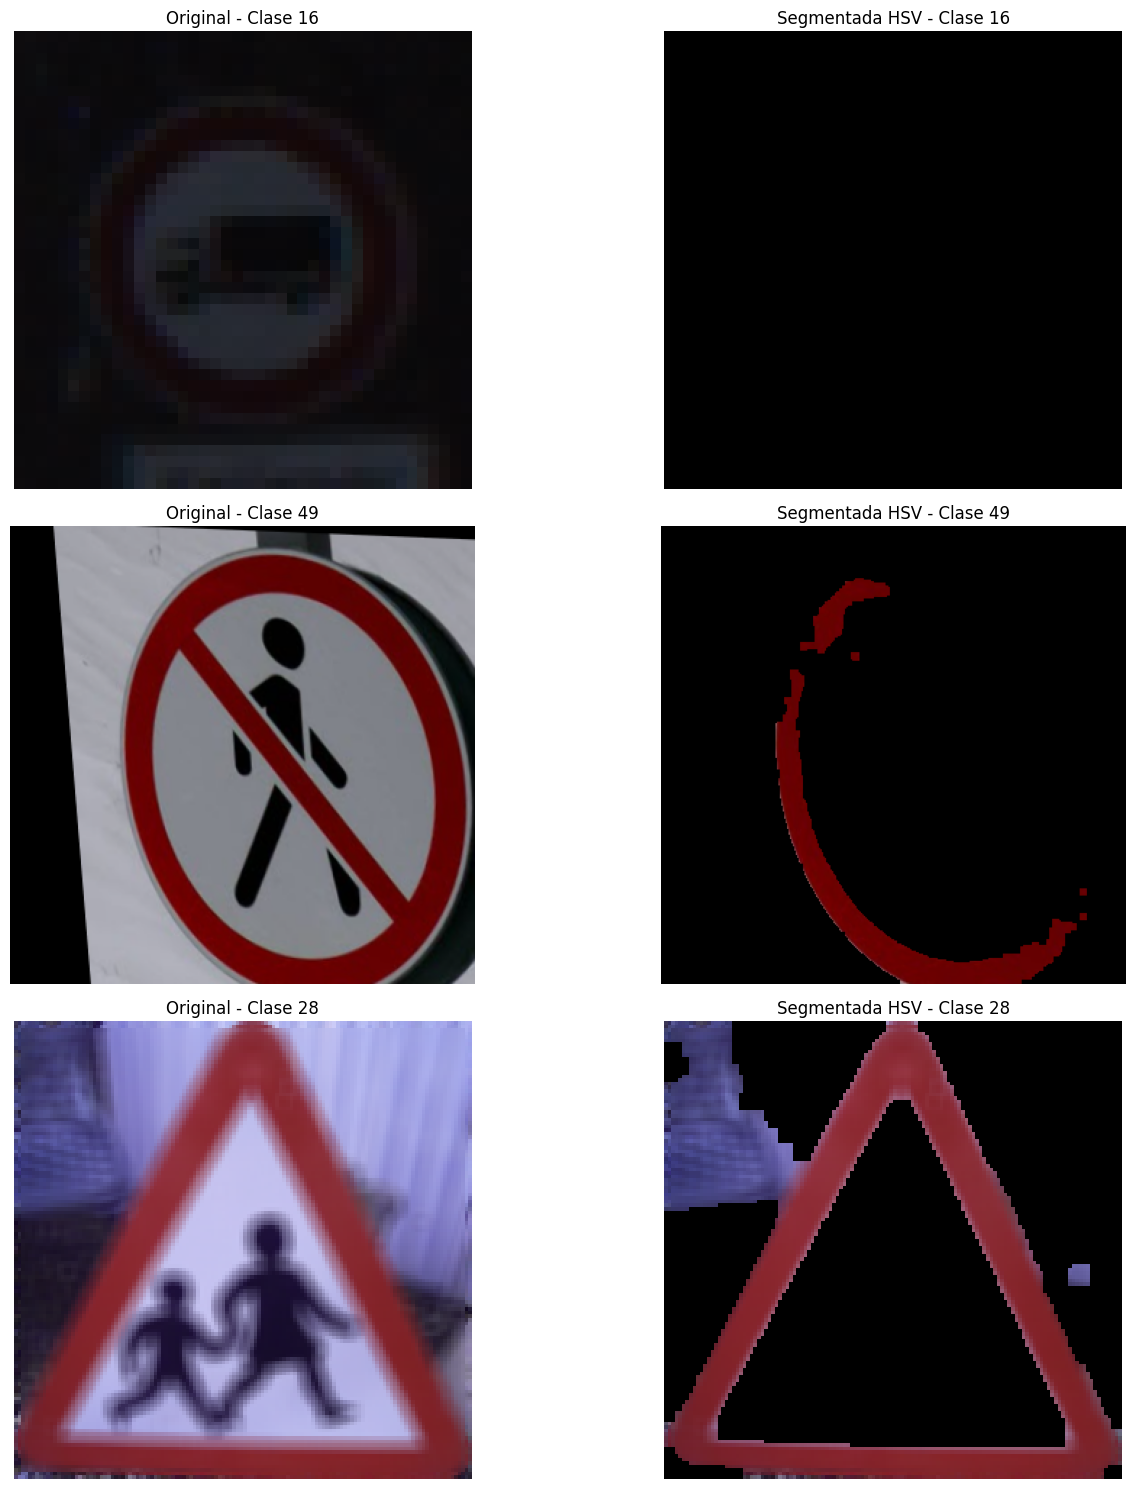

In [7]:
def visualizar_resultados_hsv(resultados_hsv, num_muestras=3):
    """
    Visualiza los resultados de la segmentación HSV mostrando la imagen original y la segmentada.
    
    Args:
        resultados_hsv (dict): Diccionario con los resultados de la segmentación
        num_muestras (int): Número de muestras aleatorias a visualizar
    """
    # Seleccionar clases aleatorias
    clases = list(resultados_hsv.keys())
    clases_muestra = np.random.choice(clases, min(num_muestras, len(clases)), replace=False)
    
    # Configurar el tamaño de la figura
    fig = plt.figure(figsize=(15, 5 * num_muestras))
    
    for i, clase in enumerate(clases_muestra):
        if not resultados_hsv[clase]:  # Si no hay resultados para esta clase
            continue
            
        # Seleccionar una imagen aleatoria de esta clase
        resultado = np.random.choice(resultados_hsv[clase])
        
        # Leer imágenes
        img_original = cv2.cvtColor(cv2.imread(resultado['ruta_original']), cv2.COLOR_BGR2RGB)
        img_segmentada = cv2.cvtColor(cv2.imread(resultado['ruta_segmentada']), cv2.COLOR_BGR2RGB)
        
        # Mostrar imágenes
        plt.subplot(num_muestras, 2, 2*i + 1)
        plt.imshow(img_original)
        plt.title(f"Original - Clase {clase}")
        plt.axis('off')
        
        plt.subplot(num_muestras, 2, 2*i + 2)
        plt.imshow(img_segmentada)
        plt.title(f"Segmentada HSV - Clase {clase}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar algunos resultados aleatorios
visualizar_resultados_hsv(resultados_hsv, num_muestras=3)

## Detección de señales de tráfico con YOLO
Implementación de un pipeline para utilizar un modelo YOLO preentrenado para la detección de señales de tráfico.

In [10]:
# Instalación de dependencias necesarias para YOLO
#!pip install ultralytics opencv-python matplotlib torch torchvision tqdm

# Verificar la instalación
import sys
print(f"Python version: {sys.version}")
!uv pip list | grep -E "ultralytics|opencv-python|matplotlib|torch|tqdm" #Cambiar si no se usa uv como gestor de paquetes

Python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Using Python 3.12.3 environment at: /home/christianr/umia_projects/UMU-MAI/.venv
matplotlib               3.10.7
matplotlib-inline        0.2.1
opencv-python            4.12.0.88
torch                    2.9.0
torchvision              0.24.0
tqdm                     4.67.1
ultralytics              8.3.221
ultralytics-thop         2.0.17


In [11]:
# Revisando GPU
import torch
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo CUDA: {torch.cuda.get_device_name(0)}")
    print(f"Número de dispositivos CUDA: {torch.cuda.device_count()}")
else:
    print("Solo CPU")

CUDA disponible: True
Dispositivo CUDA: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Número de dispositivos CUDA: 1


In [1]:
# Cargar el modelo YOLO preentrenado
from ultralytics import YOLO

# Usando YOLOv11n entrenado con señales de tráfico 
model = YOLO('models/best.pt') # https://github.com/bhaskrr/traffic-sign-detection-using-yolov11
print(f"Modelo YOLO cargado con {len(model.model.names)} clases")
print(model.model.names)

Modelo YOLO cargado con 43 clases
{0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '26', 20: '27', 21: '28', 22: '29', 23: '3', 24: '30', 25: '31', 26: '32', 27: '33', 28: '34', 29: '35', 30: '36', 31: '37', 32: '38', 33: '39', 34: '4', 35: '40', 36: '41', 37: '42', 38: '5', 39: '6', 40: '7', 41: '8', 42: '9'}


In [13]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
import cv2

def procesar_diccionario_imagenes(muestra_imagenes, modelo, conf_threshold=0.25):
    """
    Procesa las imágenes contenidas en un diccionario usando el modelo YOLO.
    
    Args:
        muestra_imagenes (dict): Diccionario donde las llaves son clases ('0' a '62') 
                              y los valores son rutas a imágenes
        modelo: Modelo YOLO cargado
        conf_threshold (float): Umbral de confianza para las detecciones (0-1)
        
    Returns:
        pd.DataFrame: DataFrame con los resultados de las predicciones
    """
    # Lista para almacenar los resultados
    resultados = []
    
    # Configurar dispositivo para usar GPU si está disponible
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Usando dispositivo: {device}")
    
    # Procesar cada clase en el diccionario
    for clase, rutas_imagenes in tqdm(muestra_imagenes.items(), desc="Procesando clases"):
        # Si rutas_imagenes es una sola ruta (string), convertirla a lista
        if isinstance(rutas_imagenes, str):
            rutas_imagenes = [rutas_imagenes]
        
        # Procesar cada imagen de la clase
        for ruta_imagen in rutas_imagenes:
            # Verificar que la imagen existe
            if not os.path.exists(ruta_imagen):
                print(f"Advertencia: La imagen {ruta_imagen} no existe. Saltando...")
                continue
                
            try:
                # Realizar la detección con el modelo YOLO
                results = modelo(ruta_imagen, conf=conf_threshold, device=device)
                result = results[0]  # Tomamos el primer resultado (una sola imagen)
                
                # Si no hay detecciones, añadir una fila con valores nulos para las detecciones
                if len(result.boxes) == 0:
                    resultados.append({
                        'clase_real': clase,
                        'ruta_imagen': ruta_imagen,
                        'clase_predicha': None,
                        'confianza': None,
                        'bbox': None
                    })
                else:
                    # Para cada detección en la imagen
                    for box in result.boxes:
                        cls_id = int(box.cls.item())
                        cls_name = result.names[cls_id]
                        conf = box.conf.item()
                        bbox = box.xyxy.tolist()[0]  # Convertir a lista [x1, y1, x2, y2]
                        
                        # Añadir resultado a la lista
                        resultados.append({
                            'clase_real': clase,
                            'ruta_imagen': ruta_imagen,
                            'clase_predicha': cls_name,
                            'confianza': conf,
                            'bbox': bbox
                        })
            except Exception as e:
                print(f"Error al procesar la imagen {ruta_imagen}: {str(e)}")
                # Añadir fila con error
                resultados.append({
                    'clase_real': clase,
                    'ruta_imagen': ruta_imagen,
                    'clase_predicha': 'ERROR',
                    'confianza': None,
                    'bbox': None,
                    'error': str(e)
                })
    
    # Crear DataFrame con los resultados
    df_resultados = pd.DataFrame(resultados)
    
    return df_resultados

def visualizar_resultados_muestra(df_resultados, num_muestras=3):
    """
    Visualiza una muestra de imágenes con sus predicciones.
    
    Args:
        df_resultados (pd.DataFrame): DataFrame con los resultados de las predicciones
        num_muestras (int): Número de imágenes a visualizar
    """
    # Filtrar solo filas con detecciones válidas
    df_con_detecciones = df_resultados[df_resultados['clase_predicha'].notna() & 
                                     (df_resultados['clase_predicha'] != 'ERROR')]
    
    # Si no hay detecciones válidas, mostrar mensaje
    if len(df_con_detecciones) == 0:
        print("No hay detecciones válidas para visualizar.")
        return
    
    # Seleccionar imágenes únicas para visualizar
    rutas_unicas = df_con_detecciones['ruta_imagen'].unique()
    num_muestras = min(num_muestras, len(rutas_unicas))
    rutas_muestra = np.random.choice(rutas_unicas, num_muestras, replace=False)
    
    # Configurar el tamaño de la figura
    plt.figure(figsize=(15, 5 * num_muestras))
    
    # Visualizar cada imagen seleccionada
    for i, ruta_imagen in enumerate(rutas_muestra):
        # Obtener todas las detecciones para esta imagen
        detecciones = df_con_detecciones[df_con_detecciones['ruta_imagen'] == ruta_imagen]
        clase_real = detecciones['clase_real'].iloc[0]
        
        # Cargar la imagen
        imagen = cv2.imread(ruta_imagen)
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        
        # Dibujar las detecciones en la imagen
        for _, det in detecciones.iterrows():
            if det['bbox'] is not None:
                x1, y1, x2, y2 = map(int, det['bbox'])
                cv2.rectangle(imagen, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # Añadir etiqueta con clase y confianza
                etiqueta = f"{det['clase_predicha']}: {det['confianza']:.2f}"
                cv2.putText(imagen, etiqueta, (x1, y1 - 10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # Mostrar la imagen con las detecciones
        plt.subplot(num_muestras, 1, i + 1)
        plt.imshow(imagen)
        plt.title(f"Imagen: {os.path.basename(ruta_imagen)} | Clase real: {clase_real}")
        plt.axis('off')
        
        # Mostrar detalle de las detecciones
        info_detecciones = "\n".join([
            f"Detección {i+1}: {det['clase_predicha']}, Confianza: {det['confianza']:.2f}"
            for i, (_, det) in enumerate(detecciones.iterrows())
        ])
        plt.figtext(0.5, 0.01 + (i / num_muestras), info_detecciones, 
                   ha="center", fontsize=10, bbox={"facecolor":"white", "alpha":0.5})
    
    plt.tight_layout()
    plt.show()

### Caso de uso

Usando dispositivo: cuda


Procesando clases:   0%|          | 0/63 [00:00<?, ?it/s]


image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/44/00044_00001_00004.png: 608x640 1 34, 67.1ms
Speed: 18.6ms preprocess, 67.1ms inference, 2.4ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/44/00044_00006_00018.png: 640x640 1 34, 8.4ms
Speed: 7.8ms preprocess, 8.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/44/00044_00006_00009.png: 640x640 (no detections), 7.6ms
Speed: 2.2ms preprocess, 7.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/44/00044_00003_00018.png: 544x640 (no detections), 46.5ms
Sp

Procesando clases:   2%|▏         | 1/63 [00:01<01:50,  1.78s/it]


image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/7/00007_00059_00008.png: 640x640 1 15, 7.5ms
Speed: 1.4ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/7/00007_00054_00012.png: 640x640 1 15, 7.3ms
Speed: 1.2ms preprocess, 7.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/7/00007_00043_00007.png: 640x640 1 15, 7.5ms
Speed: 3.8ms preprocess, 7.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/christianr/.cache/kagglehub/datasets/msalman97/dataset-for-traffic-sign-master-app/versions/1/Dataset/Train/7/00007_00018_00015.png: 640x640 1 15, 7.7ms
Speed: 1.4ms preprocess, 7.7ms i

...

Procesando clases: 100%|██████████| 63/63 [00:07<00:00,  8.68it/s]

Resultados de la detección:


,clase_real,ruta_imagen,clase_predicha,confianza,bbox
0,44,/home/christianr/.cache/kagglehub/datasets/msa...,34,0.979539,"[0.1924414336681366, 8.148241996765137, 129.86..."
1,44,/home/christianr/.cache/kagglehub/datasets/msa...,34,0.591190,"[13.62562370300293, 18.55757713317871, 252.993..."
2,44,/home/christianr/.cache/kagglehub/datasets/msa...,None,NaN,None
3,44,/home/christianr/.cache/kagglehub/datasets/msa...,None,NaN,None
4,44,/home/christianr/.cache/kagglehub/datasets/msa...,None,NaN,None
...,...,...,...,...,...
327,47,/home/christianr/.cache/kagglehub/datasets/msa...,33,0.473317,"[13.487812042236328, 0.5511195659637451, 165.4..."
328,47,/home/christianr/.cache/kagglehub/datasets/msa...,31,0.841476,"[0.17893067002296448, 0.0, 254.89463806152344,..."
329,47,/home/christianr/.cache/kagglehub/datasets/msa...,31,0.608397,"[0.0, 0.0, 256.0, 256.0]"
330,47,/home/christianr/.cache/kagglehub/datasets/msa...,35,0.300733,"[0.0, 0.07753906399011612, 255.8455047607422, ..."



Estadísticas:
Total de imágenes procesadas: 315
Total de detecciones: 293

Distribución de clases predichas:


clase_predicha
5     28
2     16
31    13
10    13
1     13
12    12
13    11
19    10
30    10
34     9
Name: count, dtype: int64

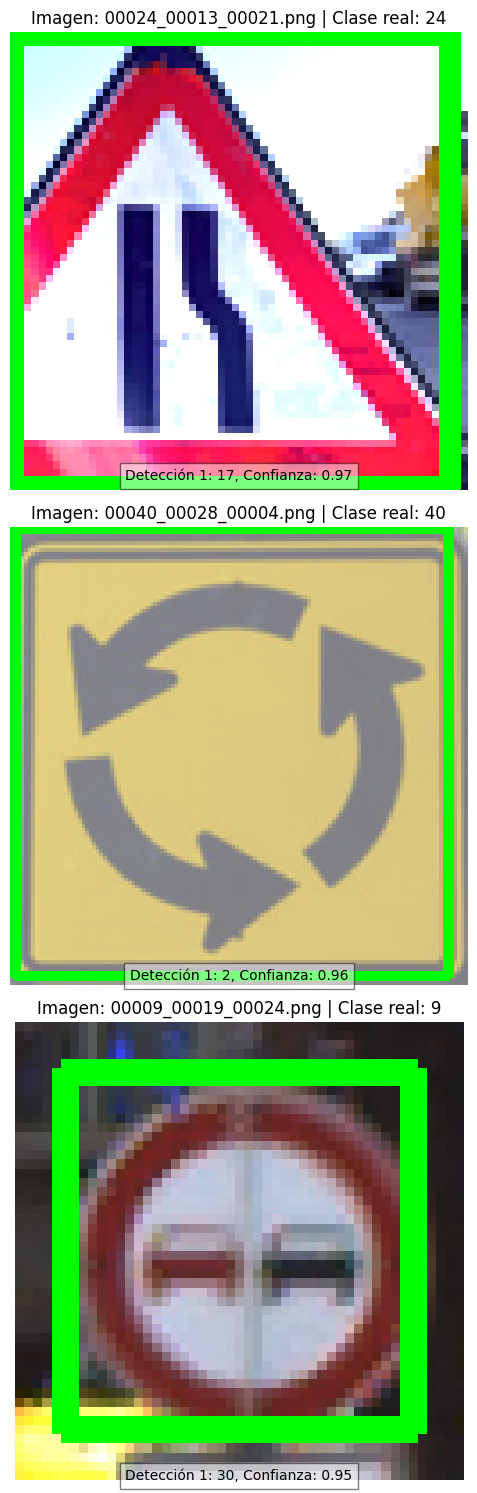

In [14]:
# Cargar el modelo YOLO
model = YOLO('models/best.pt')

# Procesar las imágenes del diccionario
df_resultados = procesar_diccionario_imagenes(muestra_imagenes, model, conf_threshold=0.25)

# Mostrar el DataFrame con los resultados
print("Resultados de la detección:")
display(df_resultados)

# Estadísticas básicas
print("\nEstadísticas:")
print(f"Total de imágenes procesadas: {df_resultados['ruta_imagen'].nunique()}")
print(f"Total de detecciones: {len(df_resultados[df_resultados['clase_predicha'].notna()])}")

# Mostrar distribución de clases predichas
if 'clase_predicha' in df_resultados.columns and df_resultados['clase_predicha'].notna().any():
    print("\nDistribución de clases predichas:")
    display(df_resultados['clase_predicha'].value_counts().head(10))

# Visualizar algunos resultados
visualizar_resultados_muestra(df_resultados, num_muestras=3)

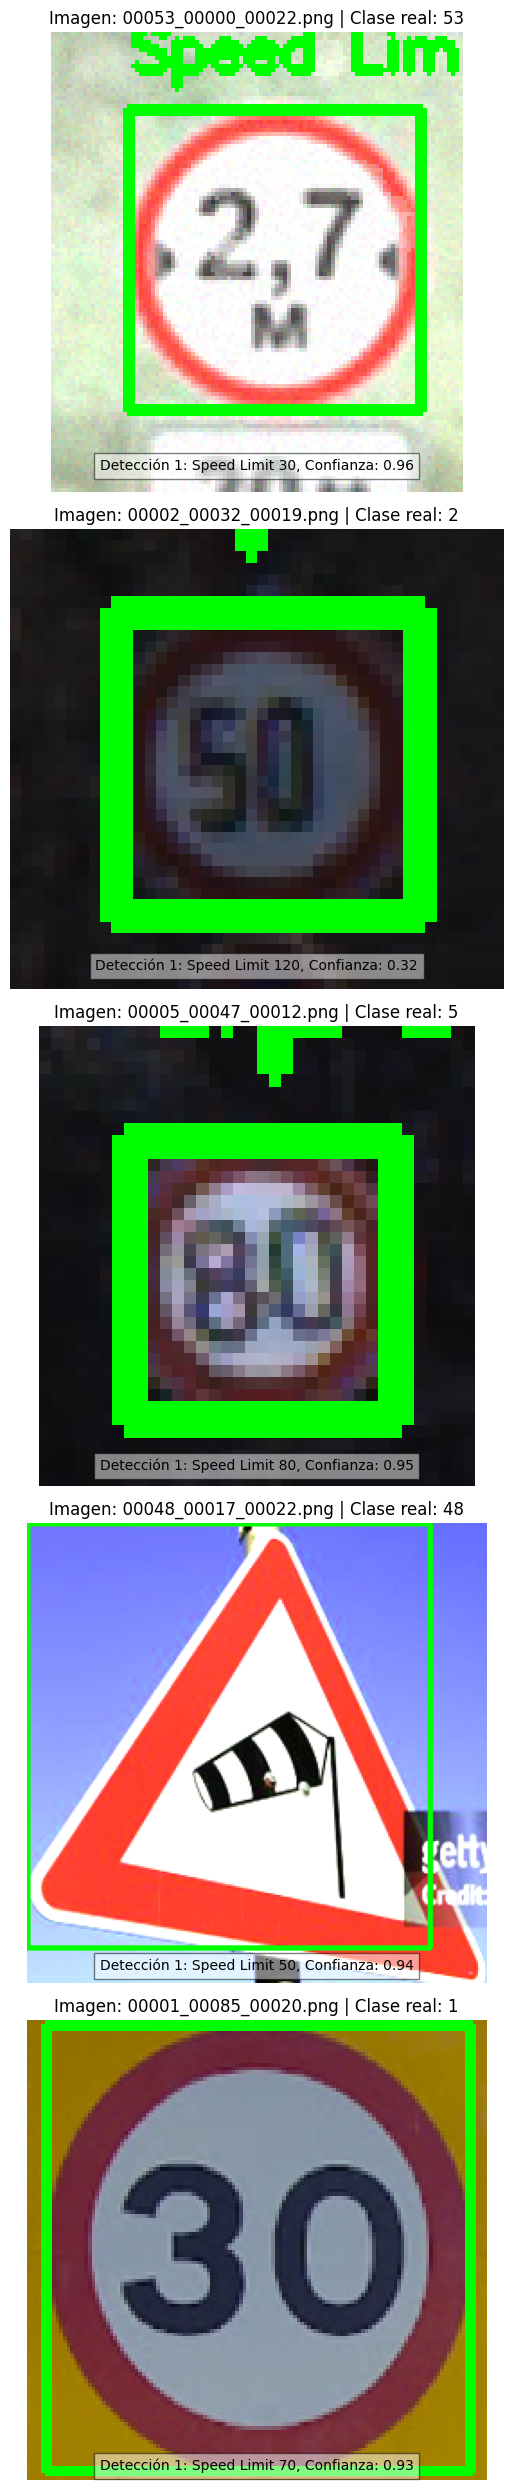

In [24]:
visualizar_resultados_muestra(df_resultados, num_muestras=5)

Procesando clases con RANSAC: 100%|██████████| 63/63 [00:06<00:00,  9.16it/s]


Pipeline RANSAC completado. Solo se guardaron imágenes con círculos detectados.


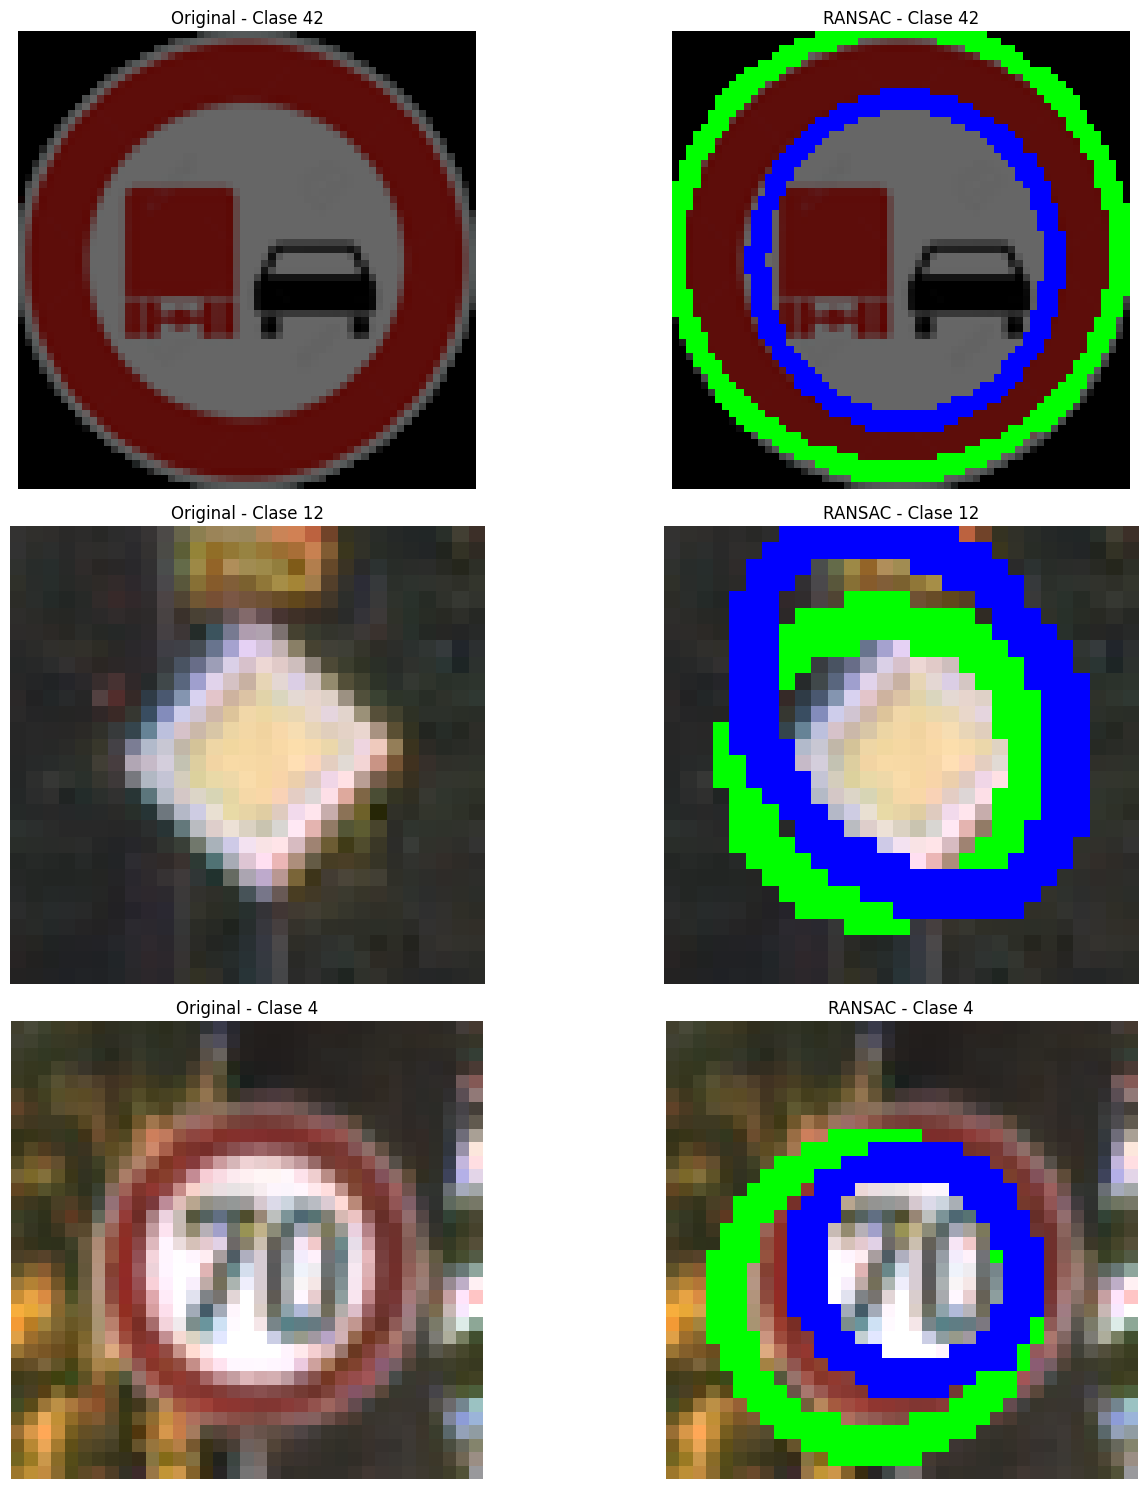

In [25]:
# ...existing code...

# Nuevo pipeline para detección de círculos y elipses con RANSAC
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

# Función para ajustar un círculo usando RANSAC
def ransac_circle(points, iterations=100, threshold=3, min_inliers=10):
    """
    Ajusta un círculo a un conjunto de puntos usando RANSAC.
    
    Args:
        points (np.array): Puntos (x, y)
        iterations (int): Número de iteraciones
        threshold (float): Umbral de distancia para inliers
        min_inliers (int): Mínimo número de inliers para considerar válido
        
    Returns:
        tuple: (centro, radio, inliers) o None si no se encuentra
    """
    best_circle = None
    best_inliers = []
    
    for _ in range(iterations):
        # Seleccionar 3 puntos aleatorios
        if len(points) < 3:
            continue
        sample = points[np.random.choice(len(points), 3, replace=False)]
        
        # Calcular el círculo que pasa por los 3 puntos
        circle = fit_circle_to_points(sample)
        if circle is None:
            continue
        
        center, radius = circle
        
        # Calcular distancias de todos los puntos al círculo
        distances = np.abs(np.sqrt((points[:, 0] - center[0])**2 + (points[:, 1] - center[1])**2) - radius)
        inliers = points[distances < threshold]
        
        if len(inliers) > len(best_inliers) and len(inliers) >= min_inliers:
            best_inliers = inliers
            best_circle = (center, radius)
    
    return best_circle, best_inliers if best_circle else None

def fit_circle_to_points(points):
    """
    Ajusta un círculo a 3 puntos.
    """
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points
    
    # Usar fórmula para círculo definido por 3 puntos
    # Centro es la intersección de las mediatrices
    temp = p2[0]*p2[0] + p2[1]*p2[1]
    bc = (p1[0]*p1[0] + p1[1]*p1[1] - temp) / 2
    cd = (temp - p3[0]*p3[0] - p3[1]*p3[1]) / 2
    det = (p1[0] - p2[0])*(p2[1] - p3[1]) - (p2[0] - p3[0])*(p1[1] - p2[1])
    
    if abs(det) < 1e-6:
        return None
    
    cx = (bc*(p2[1] - p3[1]) - cd*(p1[1] - p2[1])) / det
    cy = ((p1[0] - p2[0])*cd - (p2[0] - p3[0])*bc) / det
    radius = np.sqrt((cx - p1[0])**2 + (cy - p1[1])**2)
    
    return (cx, cy), radius

# Función para detectar elipses (simplificada, usando cv2.fitEllipse)
def detectar_elipse(contorno):
    if len(contorno) < 5:
        return None
    try:
        elipse = cv2.fitEllipse(contorno)
        return elipse
    except:
        return None

# Función principal del pipeline
def pipeline_ransac_circulos(imagen_path, output_dir, rangos_hsv):
    """
    Pipeline para detectar círculos y elipses con RANSAC, usando clasificación de tipo.
    
    Args:
        imagen_path (str): Ruta a la imagen
        output_dir (str): Directorio de salida
        rangos_hsv (dict): Rangos HSV para colores
        
    Returns:
        dict: Resultados de la detección
    """
    imagen = cv2.imread(imagen_path)
    if imagen is None:
        return None
    
    # Convertir a HSV
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v_eq = cv2.equalizeHist(v)
    hsv_eq = cv2.merge((h, s, v_eq))
    
    # Crear máscara total
    mask_total = np.zeros((imagen.shape[0], imagen.shape[1]), dtype=np.uint8)
    for nombre, (lower, upper) in rangos_hsv.items():
        mask = cv2.inRange(hsv_eq, np.array(lower), np.array(upper))
        mask_total = cv2.bitwise_or(mask_total, mask)
    
    mask_total = cv2.GaussianBlur(mask_total, (5, 5), 0)
    mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    # Encontrar contornos
    borde = cv2.Canny(mask_total, 50, 150)
    contornos, _ = cv2.findContours(borde, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contornos:
        return {'forma': 'indefinida', 'circulo_detectado': False, 'elipse_detectada': False}
    
    contorno_principal = max(contornos, key=cv2.contourArea)
    
    # Clasificar forma usando la lógica existente
    perimetro = cv2.arcLength(contorno_principal, True)
    approx = cv2.approxPolyDP(contorno_principal, 0.02 * perimetro, True)
    vertices = len(approx)
    
    if vertices == 3:
        forma = "triangulo"
    elif 4 <= vertices <= 5:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        forma = "cuadrado" if 0.9 <= aspect_ratio <= 1.1 else "rectangulo"
    elif vertices > 5:
        forma = "circulo"
    else:
        forma = "indefinida"
    
    # Si no es círculo, saltar
    if forma != "circulo":
        return {'forma': forma, 'circulo_detectado': False, 'elipse_detectada': False}
    
    # Detectar círculo con RANSAC
    puntos_borde = np.column_stack(np.where(borde > 0))
    circle, inliers = ransac_circle(puntos_borde)
    
    # Detectar elipse
    elipse = detectar_elipse(contorno_principal)
    
    # Guardar imagen con detecciones
    imagen_resultado = imagen.copy()
    if circle:
        center, radius = circle
        cv2.circle(imagen_resultado, (int(center[0]), int(center[1])), int(radius), (0, 255, 0), 2)
    if elipse:
        cv2.ellipse(imagen_resultado, elipse, (255, 0, 0), 2)
    
    nombre_archivo = os.path.basename(imagen_path)
    ruta_salida = os.path.join(output_dir, f"ransac_{nombre_archivo}")
    cv2.imwrite(ruta_salida, imagen_resultado)
    
    return {
        'forma': forma,
        'circulo_detectado': circle is not None,
        'elipse_detectada': elipse is not None,
        'ruta_resultado': ruta_salida
    }

# Definir rangos HSV (igual que en el código original)
rangos_hsv = {
    "rojo1": [(0, 40, 40), (10, 255, 255)],
    "rojo2": [(160, 40, 40), (180, 255, 255)],
    "amarillo": [(15, 60, 60), (40, 255, 255)],
    "azul": [(90, 50, 50), (130, 255, 255)]
}

# Crear directorio de salida
ransac_dir = 'out/RANSAC'
if not os.path.exists(ransac_dir):
    os.makedirs(ransac_dir)

# Procesar imágenes y filtrar solo círculos
resultados_ransac = {}
imagenes_circulos = {}

for clase, rutas_imagenes in tqdm(muestra_imagenes.items(), desc="Procesando clases con RANSAC"):
    resultados_ransac[clase] = []
    imagenes_circulos[clase] = []
    
    output_dir = os.path.join(ransac_dir, clase)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for ruta_imagen in rutas_imagenes:
        try:
            resultado = pipeline_ransac_circulos(ruta_imagen, output_dir, rangos_hsv)
            if resultado and resultado['circulo_detectado']:
                imagenes_circulos[clase].append(ruta_imagen)
                resultados_ransac[clase].append(resultado)
        except Exception as e:
            print(f"Error procesando {ruta_imagen}: {str(e)}")

print("Pipeline RANSAC completado. Solo se guardaron imágenes con círculos detectados.")

# Función para visualizar resultados
def visualizar_resultados_ransac(imagenes_circulos, num_muestras=3):
    clases = list(imagenes_circulos.keys())
    clases_muestra = np.random.choice(clases, min(num_muestras, len(clases)), replace=False)
    
    fig = plt.figure(figsize=(15, 5 * num_muestras))
    
    for i, clase in enumerate(clases_muestra):
        if not imagenes_circulos[clase]:
            continue
        
        ruta_imagen = np.random.choice(imagenes_circulos[clase])
        ruta_resultado = os.path.join(ransac_dir, clase, f"ransac_{os.path.basename(ruta_imagen)}")
        
        if os.path.exists(ruta_resultado):
            img_original = cv2.cvtColor(cv2.imread(ruta_imagen), cv2.COLOR_BGR2RGB)
            img_resultado = cv2.cvtColor(cv2.imread(ruta_resultado), cv2.COLOR_BGR2RGB)
            
            plt.subplot(num_muestras, 2, 2*i + 1)
            plt.imshow(img_original)
            plt.title(f"Original - Clase {clase}")
            plt.axis('off')
            
            plt.subplot(num_muestras, 2, 2*i + 2)
            plt.imshow(img_resultado)
            plt.title(f"RANSAC - Clase {clase}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar algunos resultados
visualizar_resultados_ransac(imagenes_circulos, num_muestras=3)

# ...existing code...

Procesando imagen de muestra: /mnt/c/Users/christianr/Downloads/archive/Traffic_dataset/Train/0/00000_00006_00026.png
Forma clasificada: circulo (vertices: 8)
Círculo detectado: Centro (50.7, 46.3), Radio 36.6
Elipse detectada


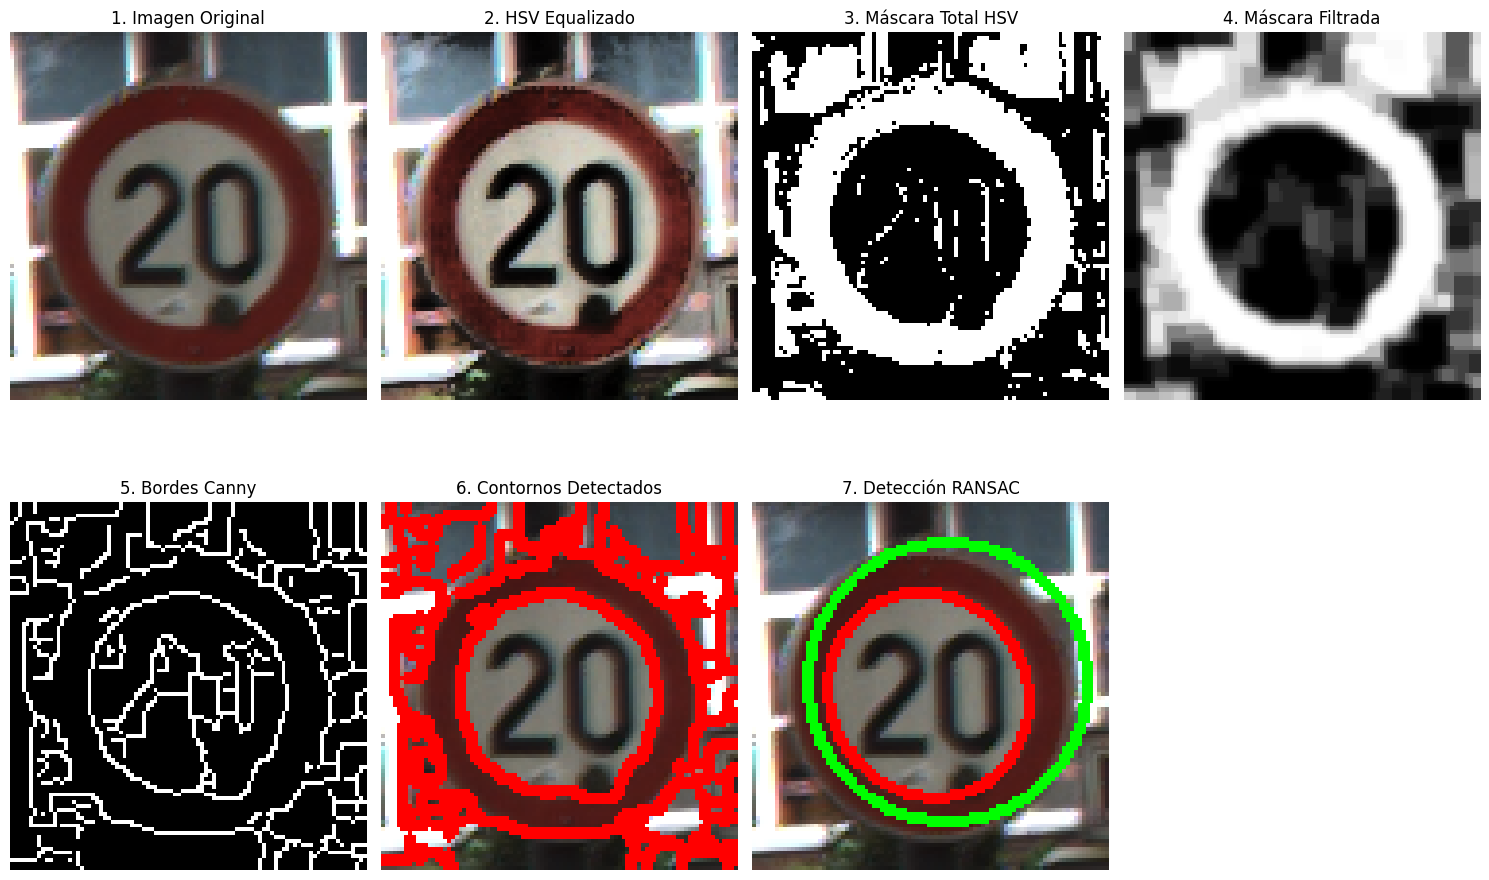

In [29]:
# Demostración paso a paso del pipeline RANSAC para una imagen de muestra
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Seleccionar una imagen de muestra (por ejemplo, la primera de la clase '0' si existe)
imagen_muestra_path = None
if '0' in muestra_imagenes and muestra_imagenes['0']:
    imagen_muestra_path = muestra_imagenes['0'][3]

if imagen_muestra_path is None:
    print("No se encontró una imagen de muestra.")
else:
    print(f"Procesando imagen de muestra: {imagen_muestra_path}")
    
    # Paso 1: Leer la imagen
    imagen = cv2.imread(imagen_muestra_path)
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(15, 10))
    plt.subplot(2, 4, 1)
    plt.imshow(imagen_rgb)
    plt.title("1. Imagen Original")
    plt.axis('off')
    
    # Paso 2: Convertir a HSV y equalizar
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v_eq = cv2.equalizeHist(v)
    hsv_eq = cv2.merge((h, s, v_eq))
    
    plt.subplot(2, 4, 2)
    plt.imshow(cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB))
    plt.title("2. HSV Equalizado")
    plt.axis('off')
    
    # Paso 3: Crear máscara total
    mask_total = np.zeros((imagen.shape[0], imagen.shape[1]), dtype=np.uint8)
    for nombre, (lower, upper) in rangos_hsv.items():
        mask = cv2.inRange(hsv_eq, np.array(lower), np.array(upper))
        mask_total = cv2.bitwise_or(mask_total, mask)
    
    plt.subplot(2, 4, 3)
    plt.imshow(mask_total, cmap='gray')
    plt.title("3. Máscara Total HSV")
    plt.axis('off')
    
    # Paso 4: Aplicar filtros morfológicos
    mask_total = cv2.GaussianBlur(mask_total, (5, 5), 0)
    mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    plt.subplot(2, 4, 4)
    plt.imshow(mask_total, cmap='gray')
    plt.title("4. Máscara Filtrada")
    plt.axis('off')
    
    # Paso 5: Detectar bordes con Canny
    borde = cv2.Canny(mask_total, 50, 150)
    
    plt.subplot(2, 4, 5)
    plt.imshow(borde, cmap='gray')
    plt.title("5. Bordes Canny")
    plt.axis('off')
    
    # Paso 6: Encontrar contornos
    contornos, _ = cv2.findContours(borde, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    imagen_contornos = imagen_rgb.copy()
    cv2.drawContours(imagen_contornos, contornos, -1, (255, 0, 0), 2)
    
    plt.subplot(2, 4, 6)
    plt.imshow(imagen_contornos)
    plt.title("6. Contornos Detectados")
    plt.axis('off')
    
    if contornos:
        contorno_principal = max(contornos, key=cv2.contourArea)
        
        # Paso 7: Clasificar forma
        perimetro = cv2.arcLength(contorno_principal, True)
        approx = cv2.approxPolyDP(contorno_principal, 0.02 * perimetro, True)
        vertices = len(approx)
        
        if vertices == 3:
            forma = "triangulo"
        elif 4 <= vertices <= 5:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            forma = "cuadrado" if 0.9 <= aspect_ratio <= 1.1 else "rectangulo"
        elif vertices > 5:
            forma = "circulo"
        else:
            forma = "indefinida"
        
        print(f"Forma clasificada: {forma} (vertices: {vertices})")
        
        # Paso 8: Si es círculo, aplicar RANSAC
        if forma == "circulo":
            puntos_borde = np.column_stack(np.where(borde > 0))
            circle, inliers = ransac_circle(puntos_borde)
            
            imagen_resultado = imagen_rgb.copy()
            if circle:
                center, radius = circle
                cv2.circle(imagen_resultado, (int(center[0]), int(center[1])), int(radius), (0, 255, 0), 2)
                print(f"Círculo detectado: Centro ({center[0]:.1f}, {center[1]:.1f}), Radio {radius:.1f}")
            
            # Detectar elipse
            elipse = detectar_elipse(contorno_principal)
            if elipse:
                cv2.ellipse(imagen_resultado, elipse, (255, 0, 0), 2)
                print("Elipse detectada")
            
            plt.subplot(2, 4, 7)
            plt.imshow(imagen_resultado)
            plt.title("7. Detección RANSAC")
            plt.axis('off')
        else:
            plt.subplot(2, 4, 7)
            plt.imshow(imagen_rgb)
            plt.title("7. No es círculo")
            plt.axis('off')
    else:
        print("No se encontraron contornos.")
        plt.subplot(2, 4, 7)
        plt.imshow(imagen_rgb)
        plt.title("7. Sin contornos")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


Procesando clases con Sobel: 100%|██████████| 63/63 [00:11<00:00,  5.49it/s]


Pipeline Sobel completado. Solo se guardaron imágenes con círculos detectados.


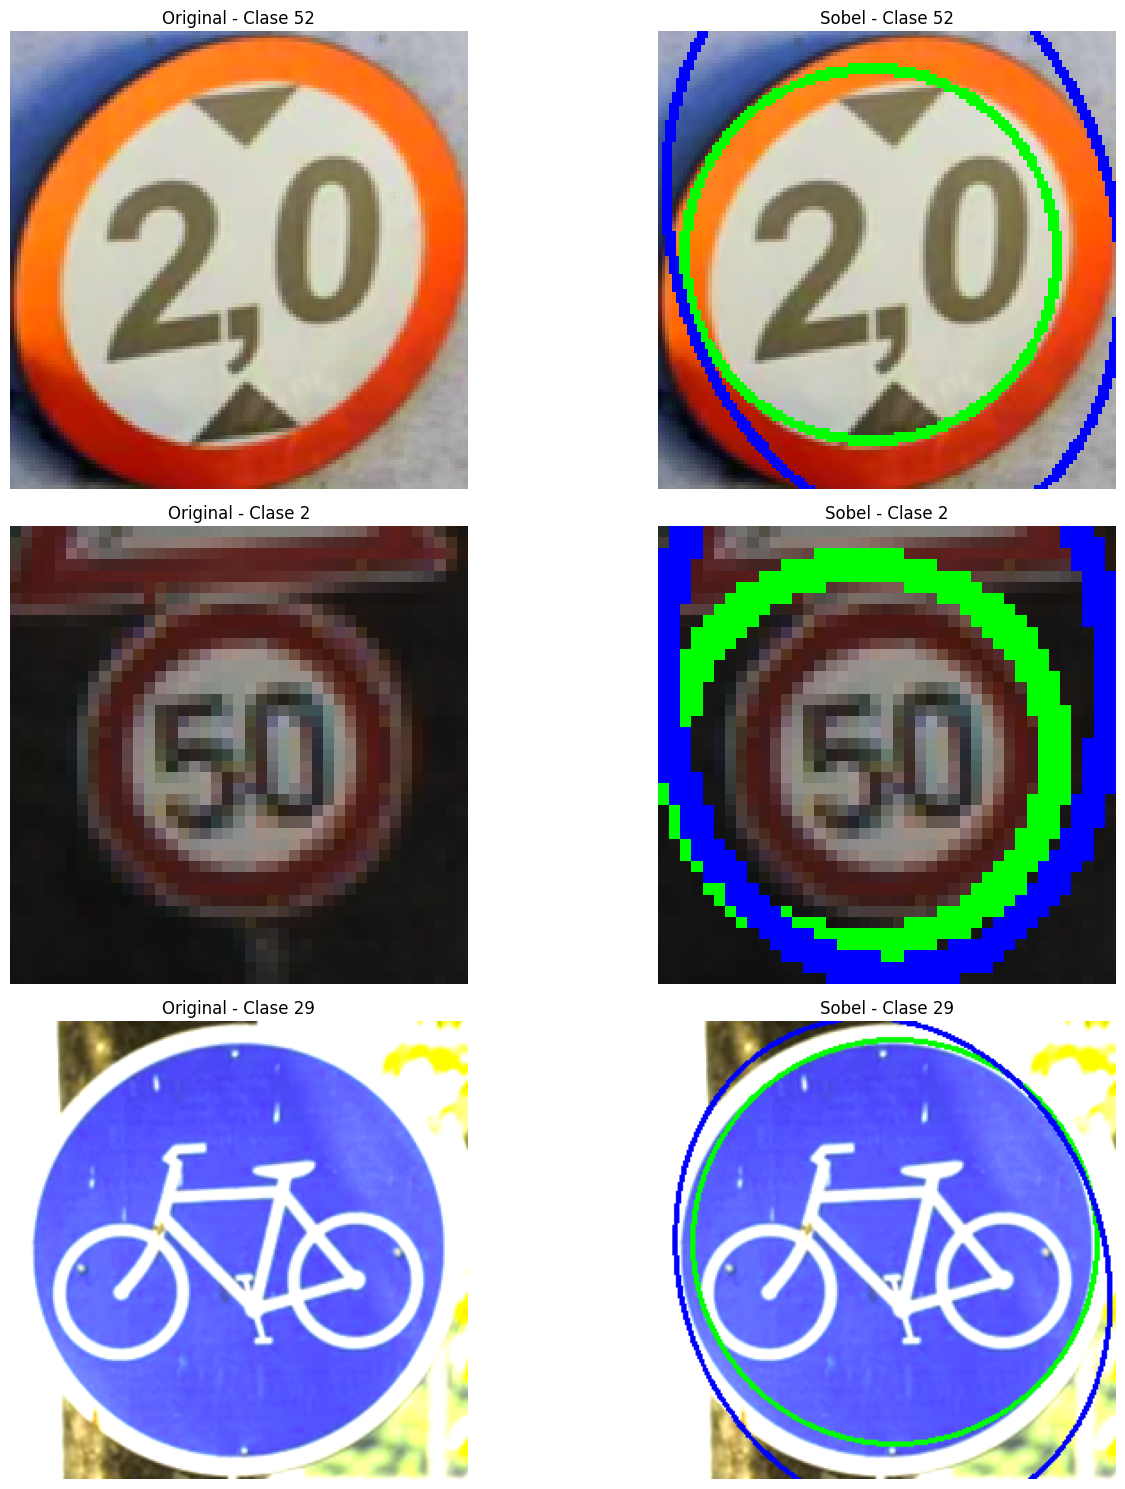

In [30]:
# ...existing code...

# Nuevo pipeline alternativo usando Sobel para detección de círculos y elipses con RANSAC
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

# Función para obtener máscara binaria usando Sobel
def sobel_mask(img_gray, threshold=50):
    """
    Aplica Sobel para detectar gradientes y umbraliza para obtener máscara binaria.
    
    Args:
        img_gray (np.array): Imagen en escala de grises
        threshold (int): Umbral para binarizar la magnitud de gradientes
        
    Returns:
        np.array: Máscara binaria de bordes
    """
    # Calcular gradientes con Sobel
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    
    # Umbralizar para obtener máscara binaria
    _, mask = cv2.threshold(magnitude.astype(np.uint8), threshold, 255, cv2.THRESH_BINARY)
    
    return mask

# Función para ajustar un círculo usando RANSAC (igual que antes)
def ransac_circle(points, iterations=100, threshold=3, min_inliers=10):
    """
    Ajusta un círculo a un conjunto de puntos usando RANSAC.
    
    Args:
        points (np.array): Puntos (x, y)
        iterations (int): Número de iteraciones
        threshold (float): Umbral de distancia para inliers
        min_inliers (int): Mínimo número de inliers para considerar válido
        
    Returns:
        tuple: (centro, radio, inliers) o None si no se encuentra
    """
    best_circle = None
    best_inliers = []
    
    for _ in range(iterations):
        # Seleccionar 3 puntos aleatorios
        if len(points) < 3:
            continue
        sample = points[np.random.choice(len(points), 3, replace=False)]
        
        # Calcular el círculo que pasa por los 3 puntos
        circle = fit_circle_to_points(sample)
        if circle is None:
            continue
        
        center, radius = circle
        
        # Calcular distancias de todos los puntos al círculo
        distances = np.abs(np.sqrt((points[:, 0] - center[0])**2 + (points[:, 1] - center[1])**2) - radius)
        inliers = points[distances < threshold]
        
        if len(inliers) > len(best_inliers) and len(inliers) >= min_inliers:
            best_inliers = inliers
            best_circle = (center, radius)
    
    return best_circle, best_inliers if best_circle else None

def fit_circle_to_points(points):
    """
    Ajusta un círculo a 3 puntos.
    """
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points
    
    # Usar fórmula para círculo definido por 3 puntos
    temp = p2[0]*p2[0] + p2[1]*p2[1]
    bc = (p1[0]*p1[0] + p1[1]*p1[1] - temp) / 2
    cd = (temp - p3[0]*p3[0] - p3[1]*p3[1]) / 2
    det = (p1[0] - p2[0])*(p2[1] - p3[1]) - (p2[0] - p3[0])*(p1[1] - p2[1])
    
    if abs(det) < 1e-6:
        return None
    
    cx = (bc*(p2[1] - p3[1]) - cd*(p1[1] - p2[1])) / det
    cy = ((p1[0] - p2[0])*cd - (p2[0] - p3[0])*bc) / det
    radius = np.sqrt((cx - p1[0])**2 + (cy - p1[1])**2)
    
    return (cx, cy), radius

# Función para detectar elipses (igual que antes)
def detectar_elipse(contorno):
    if len(contorno) < 5:
        return None
    try:
        elipse = cv2.fitEllipse(contorno)
        return elipse
    except:
        return None

# Función principal del pipeline con Sobel
def pipeline_sobel_circulos(imagen_path, output_dir):
    """
    Pipeline alternativo usando Sobel para detectar círculos y elipses con RANSAC.
    
    Args:
        imagen_path (str): Ruta a la imagen
        output_dir (str): Directorio de salida
        
    Returns:
        dict: Resultados de la detección
    """
    imagen = cv2.imread(imagen_path)
    if imagen is None:
        return None
    
    # Convertir a gris
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Aplicar Sobel para obtener máscara binaria
    mask_total = sobel_mask(gray, threshold=50)
    
    # Aplicar operaciones morfológicas para mejorar
    mask_total = cv2.GaussianBlur(mask_total, (5, 5), 0)
    mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    # Encontrar contornos
    contornos, _ = cv2.findContours(mask_total, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contornos:
        return {'forma': 'indefinida', 'circulo_detectado': False, 'elipse_detectada': False}
    
    contorno_principal = max(contornos, key=cv2.contourArea)
    
    # Clasificar forma usando la lógica existente
    perimetro = cv2.arcLength(contorno_principal, True)
    approx = cv2.approxPolyDP(contorno_principal, 0.02 * perimetro, True)
    vertices = len(approx)
    
    if vertices == 3:
        forma = "triangulo"
    elif 4 <= vertices <= 5:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        forma = "cuadrado" if 0.9 <= aspect_ratio <= 1.1 else "rectangulo"
    elif vertices > 5:
        forma = "circulo"
    else:
        forma = "indefinida"
    
    # Si no es círculo, saltar
    if forma != "circulo":
        return {'forma': forma, 'circulo_detectado': False, 'elipse_detectada': False}
    
    # Detectar círculo con RANSAC
    puntos_borde = np.column_stack(np.where(mask_total > 0))
    circle, inliers = ransac_circle(puntos_borde)
    
    # Detectar elipse
    elipse = detectar_elipse(contorno_principal)
    
    # Guardar imagen con detecciones
    imagen_resultado = imagen.copy()
    if circle:
        center, radius = circle
        cv2.circle(imagen_resultado, (int(center[0]), int(center[1])), int(radius), (0, 255, 0), 2)
    if elipse:
        cv2.ellipse(imagen_resultado, elipse, (255, 0, 0), 2)
    
    nombre_archivo = os.path.basename(imagen_path)
    ruta_salida = os.path.join(output_dir, f"sobel_{nombre_archivo}")
    cv2.imwrite(ruta_salida, imagen_resultado)
    
    return {
        'forma': forma,
        'circulo_detectado': circle is not None,
        'elipse_detectada': elipse is not None,
        'ruta_resultado': ruta_salida
    }

# Crear directorio de salida
sobel_dir = 'out/Sobel'
if not os.path.exists(sobel_dir):
    os.makedirs(sobel_dir)

# Procesar imágenes y filtrar solo círculos
resultados_sobel = {}
imagenes_circulos_sobel = {}

for clase, rutas_imagenes in tqdm(muestra_imagenes.items(), desc="Procesando clases con Sobel"):
    resultados_sobel[clase] = []
    imagenes_circulos_sobel[clase] = []
    
    output_dir = os.path.join(sobel_dir, clase)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for ruta_imagen in rutas_imagenes:
        try:
            resultado = pipeline_sobel_circulos(ruta_imagen, output_dir)
            if resultado and resultado['circulo_detectado']:
                imagenes_circulos_sobel[clase].append(ruta_imagen)
                resultados_sobel[clase].append(resultado)
        except Exception as e:
            print(f"Error procesando {ruta_imagen}: {str(e)}")

print("Pipeline Sobel completado. Solo se guardaron imágenes con círculos detectados.")

# Función para visualizar resultados
def visualizar_resultados_sobel(imagenes_circulos, num_muestras=3):
    clases = list(imagenes_circulos.keys())
    clases_muestra = np.random.choice(clases, min(num_muestras, len(clases)), replace=False)
    
    fig = plt.figure(figsize=(15, 5 * num_muestras))
    
    for i, clase in enumerate(clases_muestra):
        if not imagenes_circulos[clase]:
            continue
        
        ruta_imagen = np.random.choice(imagenes_circulos[clase])
        ruta_resultado = os.path.join(sobel_dir, clase, f"sobel_{os.path.basename(ruta_imagen)}")
        
        if os.path.exists(ruta_resultado):
            img_original = cv2.cvtColor(cv2.imread(ruta_imagen), cv2.COLOR_BGR2RGB)
            img_resultado = cv2.cvtColor(cv2.imread(ruta_resultado), cv2.COLOR_BGR2RGB)
            
            plt.subplot(num_muestras, 2, 2*i + 1)
            plt.imshow(img_original)
            plt.title(f"Original - Clase {clase}")
            plt.axis('off')
            
            plt.subplot(num_muestras, 2, 2*i + 2)
            plt.imshow(img_resultado)
            plt.title(f"Sobel - Clase {clase}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar algunos resultados
visualizar_resultados_sobel(imagenes_circulos_sobel, num_muestras=3)

# ...existing code...

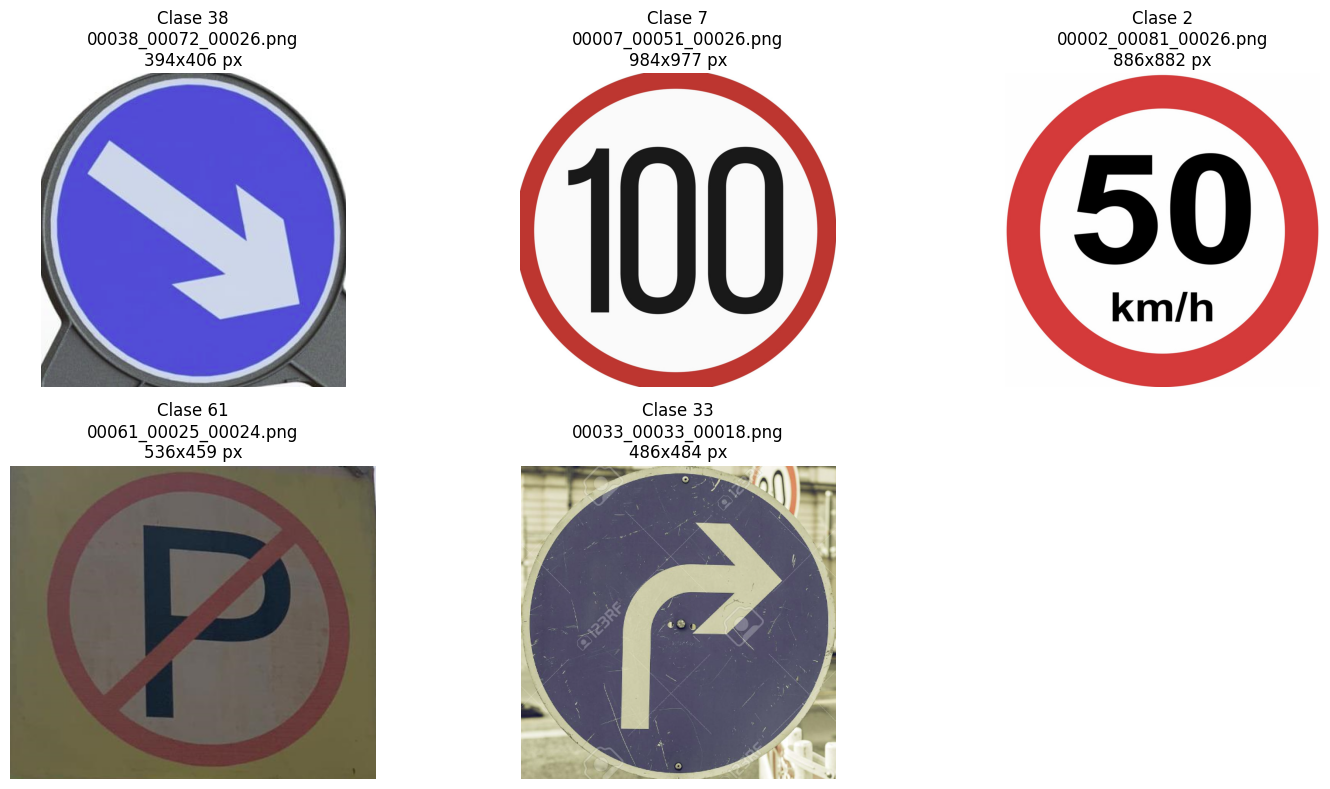

In [ ]:
# ...existing code...

def mostrar_imagen_mas_grande_por_clase(dir_train, num_clases_mostrar=5, semilla=42):
    """
    Muestra la imagen más grande (por área de píxeles) de cada clase seleccionada en una sola figura.
    
    Args:
        dir_train (str): Ruta al directorio Train del dataset.
        num_clases_mostrar (int): Número de clases a mostrar en la figura.
        semilla (int): Semilla para reproducibilidad en la selección de clases.
    """
    import os
    import cv2
    import matplotlib.pyplot as plt
    import random
    
    # Verificar que el directorio existe
    if not os.path.exists(dir_train):
        print(f"El directorio {dir_train} no existe.")
        return
    
    # Obtener lista de clases (subdirectorios)
    clases = [d for d in os.listdir(dir_train) if os.path.isdir(os.path.join(dir_train, d))]
    clases.sort()  # Ordenar para reproducibilidad
    
    # Seleccionar aleatoriamente num_clases_mostrar clases
    random.seed(semilla)
    clases_seleccionadas = random.sample(clases, min(num_clases_mostrar, len(clases)))
    
    # Diccionario para almacenar la imagen más grande por clase
    imagenes_mas_grandes = {}
    
    for clase in clases_seleccionadas:
        dir_clase = os.path.join(dir_train, clase)
        imagenes = [f for f in os.listdir(dir_clase) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if not imagenes:
            print(f"No hay imágenes en la clase {clase}.")
            continue
        
        # Encontrar la imagen más grande por área de píxeles
        max_area = 0
        imagen_mas_grande = None
        
        for img_file in imagenes:
            img_path = os.path.join(dir_clase, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                height, width = img.shape[:2]
                area = width * height
                if area > max_area:
                    max_area = area
                    imagen_mas_grande = img_path
        
        if imagen_mas_grande:
            imagenes_mas_grandes[clase] = imagen_mas_grande
    
    # Mostrar las imágenes en una figura
    if not imagenes_mas_grandes:
        print("No se encontraron imágenes para mostrar.")
        return
    
    num_imagenes = len(imagenes_mas_grandes)
    cols = min(3, num_imagenes)  # Máximo 3 columnas
    rows = (num_imagenes + cols - 1) // cols  # Calcular filas necesarias
    
    plt.figure(figsize=(5 * cols, 4 * rows))
    
    for i, (clase, img_path) in enumerate(imagenes_mas_grandes.items()):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width = img.shape[:2]
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"Clase {clase}\n{os.path.basename(img_path)}\n{width}x{height} px")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Uso de la función

# ...existing code...

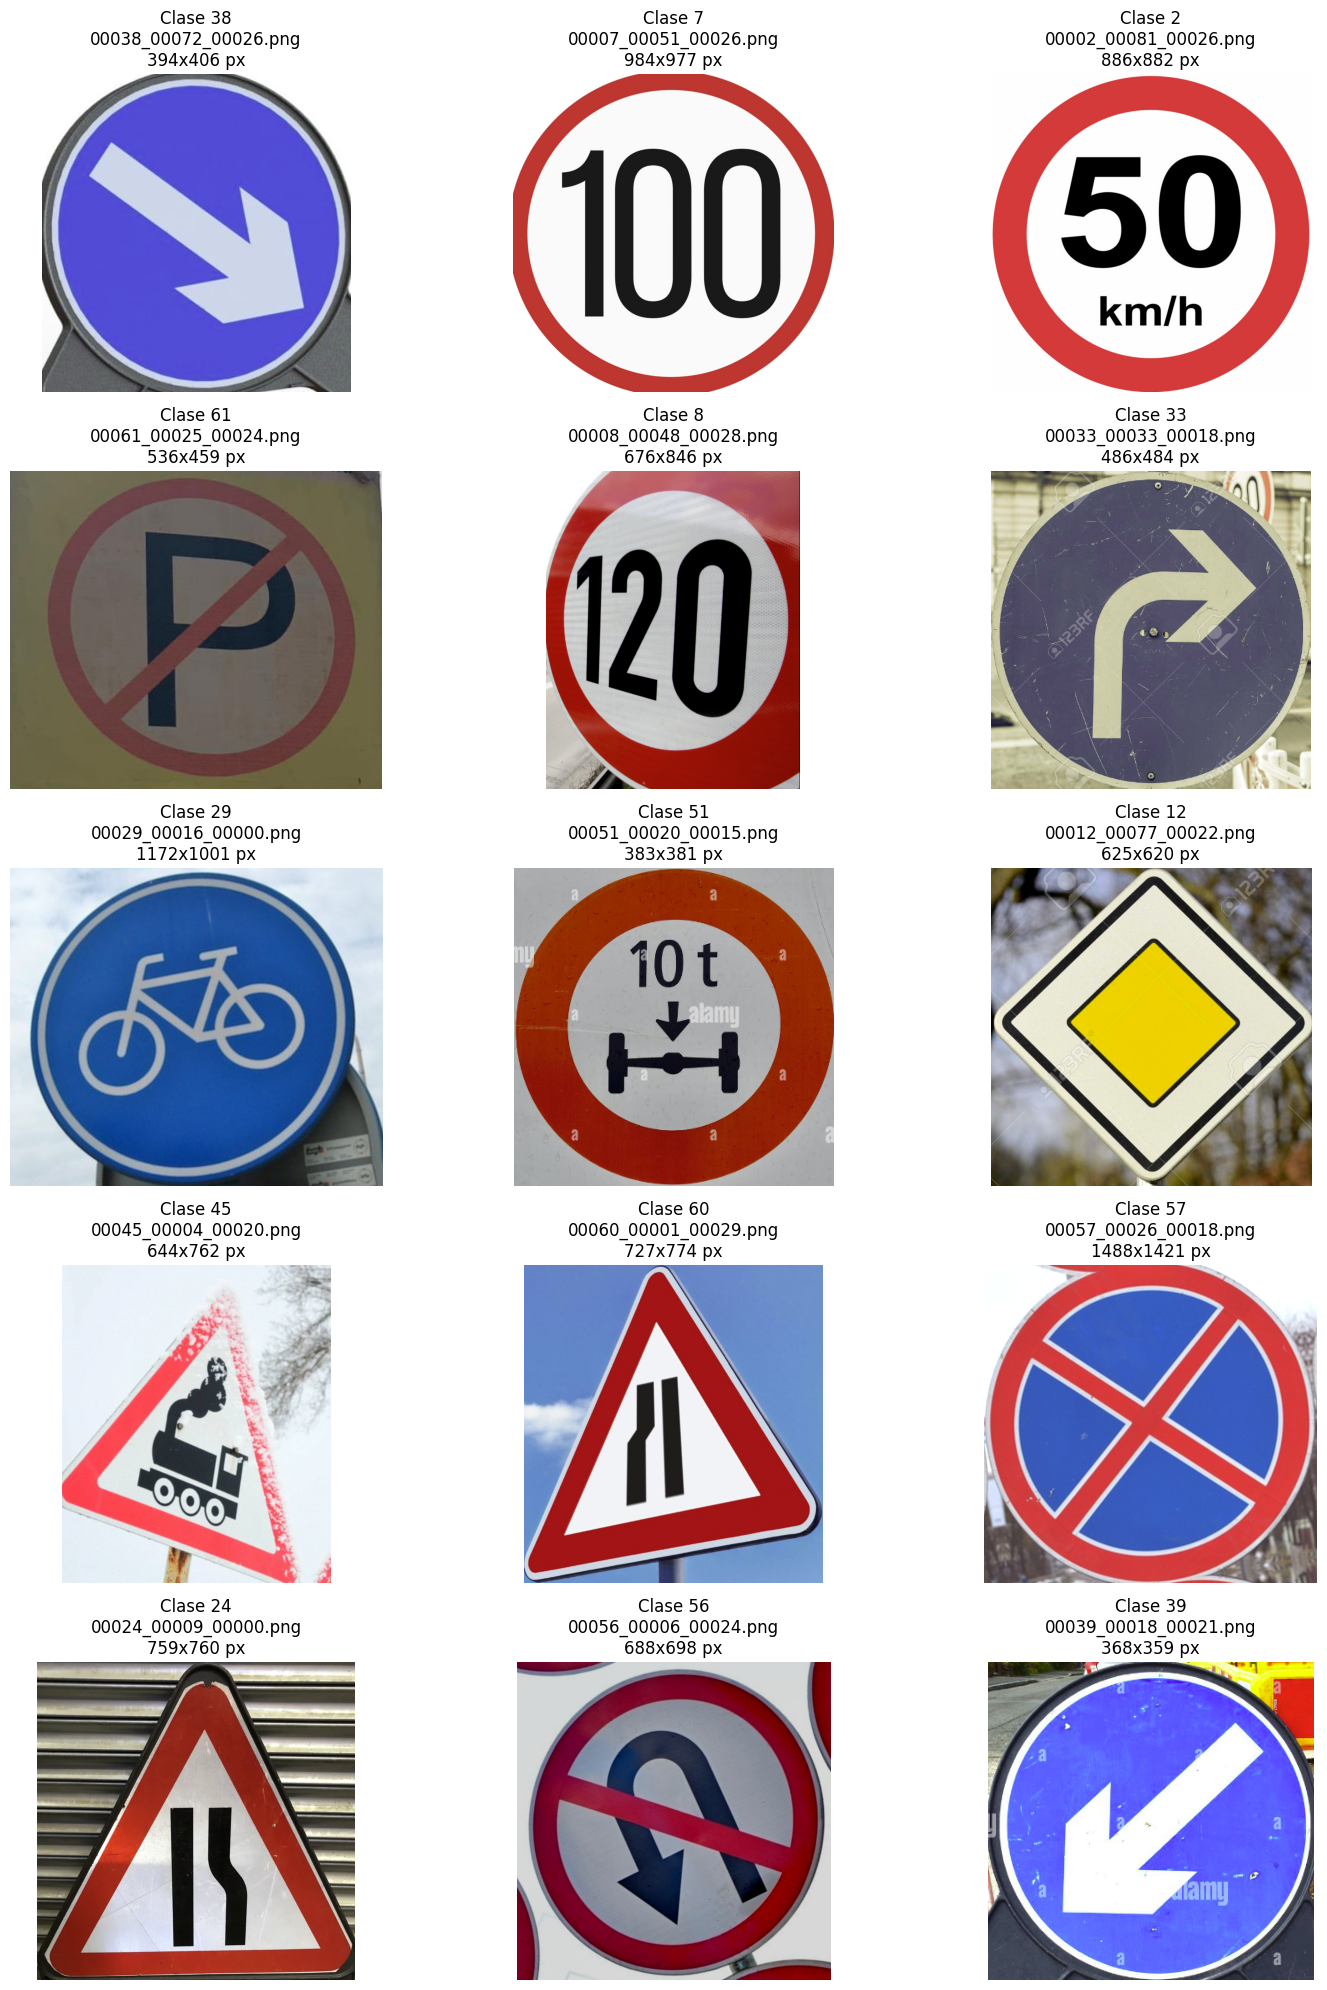

In [33]:
dir_entrenamiento = os.path.join(dir_base, "Train")
mostrar_imagen_mas_grande_por_clase(dir_entrenamiento, num_clases_mostrar=15, semilla=2212)


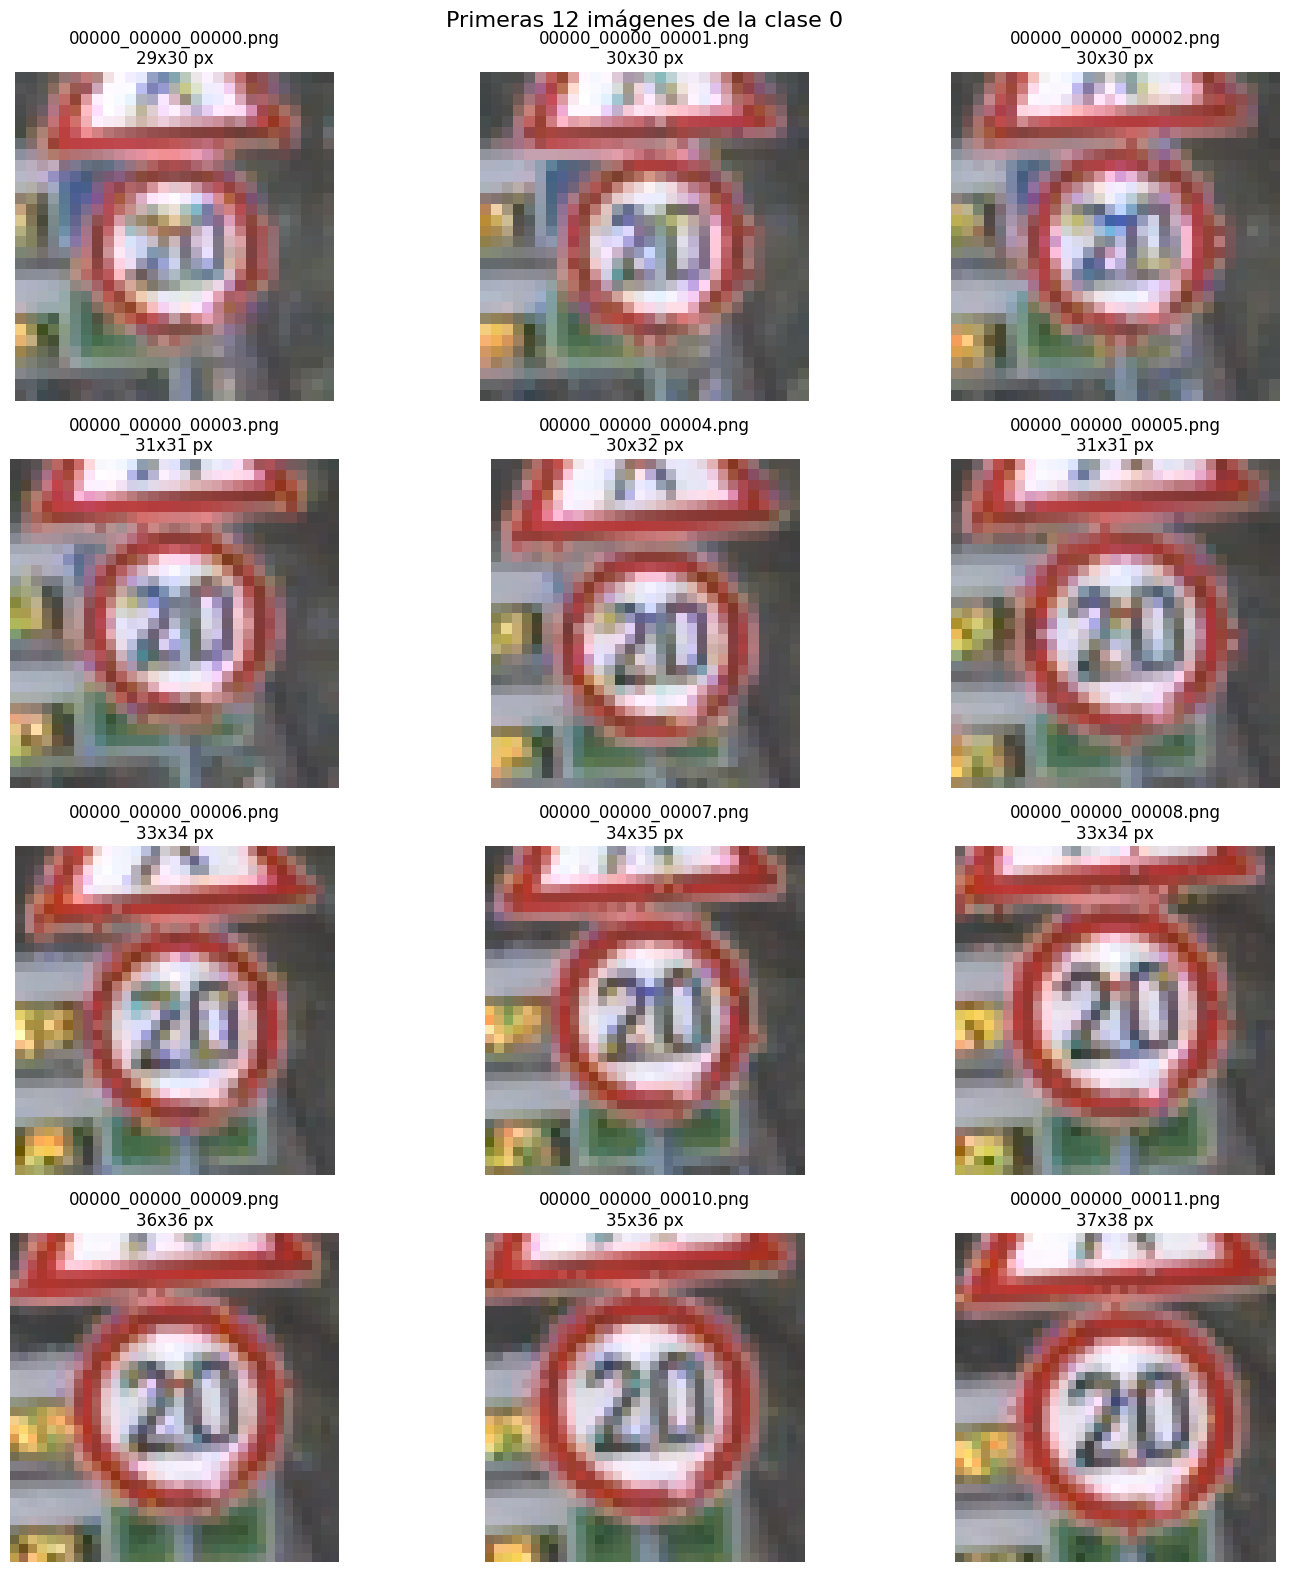

In [60]:
# ...existing code...

def mostrar_primeras_imagenes_clase(dir_train, clase, num_imagenes=5):
    """
    Muestra las primeras n imágenes de una clase específica en una sola figura.
    
    Args:
        dir_train (str): Ruta al directorio Train del dataset.
        clase (str): Nombre de la clase (e.g., '0', '10').
        num_imagenes (int): Número de imágenes a mostrar.
    """
    import os
    import cv2
    import matplotlib.pyplot as plt
    
    # Verificar que el directorio existe
    if not os.path.exists(dir_train):
        print(f"El directorio {dir_train} no existe.")
        return
    
    # Ruta al directorio de la clase
    dir_clase = os.path.join(dir_train, clase)
    if not os.path.exists(dir_clase):
        print(f"La clase {clase} no existe en {dir_train}.")
        return
    
    # Obtener lista de imágenes
    imagenes = [f for f in os.listdir(dir_clase) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    imagenes.sort()  # Ordenar alfabéticamente para consistencia
    
    if not imagenes:
        print(f"No hay imágenes en la clase {clase}.")
        return
    
    # Seleccionar las primeras num_imagenes
    imagenes_mostrar = imagenes[:num_imagenes]
    
    # Configurar la figura
    cols = min(3, len(imagenes_mostrar))  # Máximo 3 columnas
    rows = (len(imagenes_mostrar) + cols - 1) // cols
    
    plt.figure(figsize=(5 * cols, 4 * rows))
    
    for i, img_file in enumerate(imagenes_mostrar):
        img_path = os.path.join(dir_clase, img_file)
        img = cv2.imread(img_path)
        if img is None:
            print(f"No se pudo leer la imagen: {img_path}")
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width = img.shape[:2]
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"{os.path.basename(img_file)}\n{width}x{height} px")
        plt.axis('off')
    
    plt.suptitle(f"Primeras {len(imagenes_mostrar)} imágenes de la clase {clase}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Uso de la función
dir_entrenamiento = os.path.join(dir_base, "Train")
mostrar_primeras_imagenes_clase(dir_entrenamiento, clase='0', num_imagenes=12)

# ...existing code...